In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import imutils
import os
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from imutils.object_detection import non_max_suppression
import numpy as np
import imutils
import time
from PIL import Image
import cv2

In [ ]:
def sliding_window(image, step, ws):
	for y in range(0, image.shape[0] - ws[1], step):
		for x in range(0, image.shape[1] - ws[0], step):
			yield (x, y, image[y:y + ws[1], x:x + ws[0]])

In [ ]:

def image_pyramid(image, scale=1.5, minSize=(224, 224)):
	yield image
	while True:
		w = int(image.shape[1] / scale)
		image = imutils.resize(image, width=w)
		if image.shape[0] < minSize[1] or image.shape[1] < minSize[0]:
			break
		yield image

In [ ]:

WIDTH = 600
PYR_SCALE = 1.5
p_PYR_SCALE = 1.5
WIN_STEP = 15
ROI_SIZE_FACE = (100,100) #(100,100)
ROI_SIZE_PLATE = (200,200) #(200,200)

In [ ]:

f_model=modified_VGG16()
f_model.load_state_dict(torch.load('/content/drive/MyDrive/models/model_epoch_13.pt'))
f_model.eval()


p_model=p_modified_VGG16()
p_model.load_state_dict(torch.load('/content/drive/MyDrive/model_plates/slightly_better_model_epoch_1.pt'))
p_model.eval()

if torch.cuda.is_available():
    f_model.cuda()
    p_model.cuda()

img_path = '/content/man-sitting-beside-mini-cooper.jpg'

orig = cv2.imread(img_path)
orig = imutils.resize(orig, width=WIDTH)
(H, W) = orig.shape[:2]



/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:10<00:00, 52.6MB/s]


In [ ]:
print((H,W))

(450, 600)


In [ ]:

f_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

p_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
])


In [ ]:
#image pyramids :
f_pyramid = image_pyramid(orig, scale=PYR_SCALE, minSize=ROI_SIZE_FACE)
p_pyramid = image_pyramid(orig, scale=p_PYR_SCALE, minSize=ROI_SIZE_PLATE)


f_rois = []
f_locs = []

p_rois = []
p_locs = []


In [ ]:


print("[INFO] looping over pyramid/windows ")
start = time.time()
for image in f_pyramid:


	scale = W / float(image.shape[1])

	for (x, y, roiOrig) in sliding_window(image, WIN_STEP, ROI_SIZE_FACE):


		x = int(x * scale)
		y = int(y * scale)
		w = int(ROI_SIZE_FACE[0] * scale)
		h = int(ROI_SIZE_FACE[1] * scale)

		roiOrig_pil = Image.fromarray(roiOrig)
		roi = f_transform(roiOrig_pil)

		f_rois.append(roi)
		f_locs.append((x, y, x + w, y + h))
		clone = orig.copy()



[INFO] looping over pyramid/windows 


In [ ]:

for image in p_pyramid:


	scale = W / float(image.shape[1])

	for (x, y, roiOrig) in sliding_window(image, WIN_STEP, ROI_SIZE_PLATE):


		x = int(x * scale)
		y = int(y * scale)
		w = int(ROI_SIZE_PLATE[0] * scale)
		h = int(ROI_SIZE_PLATE[1] * scale)

		roiOrig_pil = Image.fromarray(roiOrig)
		roi = p_transform(roiOrig_pil)

		p_rois.append(roi)
		p_locs.append((x, y, x + w, y + h))


end = time.time()
print("[INFO] looping over pyramid/windows took {:.5f} seconds".format(end - start))

[INFO] looping over pyramid/windows took 4.95069 seconds


In [ ]:

print("[INFO] classifying ROIs...")
start = time.time()
with torch.no_grad():
    f_preds = []

    p_preds = []

    for roi in f_rois:
            roi = roi.unsqueeze(0)
            roi = roi.to('cuda')
            pred = f_model(roi)
            f_preds.append(pred)

    for roi in p_rois:
            roi = roi.unsqueeze(0)
            roi = roi.to('cuda')
            pred = p_model(roi)
            p_preds.append(pred)

end = time.time()
print("[INFO] classifying ROIs took {:.5f} seconds".format(end - start))

print(f_preds)
print(p_preds)


[INFO] classifying ROIs...
[INFO] classifying ROIs took 20.36451 seconds
[tensor([0.9993], device='cuda:0'), tensor([0.9995], device='cuda:0'), tensor([0.9998], device='cuda:0'), tensor([1.0000], device='cuda:0'), tensor([0.9996], device='cuda:0'), tensor([0.9998], device='cuda:0'), tensor([0.9997], device='cuda:0'), tensor([0.9996], device='cuda:0'), tensor([0.9996], device='cuda:0'), tensor([0.9998], device='cuda:0'), tensor([0.9952], device='cuda:0'), tensor([0.9989], device='cuda:0'), tensor([0.9999], device='cuda:0'), tensor([0.9978], device='cuda:0'), tensor([0.9997], device='cuda:0'), tensor([0.9994], device='cuda:0'), tensor([0.9995], device='cuda:0'), tensor([0.9998], device='cuda:0'), tensor([0.9895], device='cuda:0'), tensor([0.9979], device='cuda:0'), tensor([0.9992], device='cuda:0'), tensor([0.9996], device='cuda:0'), tensor([0.9986], device='cuda:0'), tensor([0.9998], device='cuda:0'), tensor([0.9998], device='cuda:0'), tensor([0.9997], device='cuda:0'), tensor([0.9999],

In [ ]:

f_bbx = []
p_bbx = []

for (i , p) in enumerate(f_preds):
  prob = p[0]
  if prob < 0.5:
    box = f_locs[i]
    f_bbx.append((box, prob))
print("[INFO] bbx for faces")
print(f_bbx)

for (i , p) in enumerate(p_preds):
  prob = p[0]
  if prob < 0.5:
    box = p_locs[i]
    p_bbx.append((box, prob))
print("[INFO] bbx for plates")
print(p_bbx)



[INFO] bbx for faces
[((285, 105, 385, 205), tensor(0.3657, device='cuda:0')), ((300, 105, 400, 205), tensor(0.0011, device='cuda:0')), ((315, 105, 415, 205), tensor(3.3260e-06, device='cuda:0')), ((330, 105, 430, 205), tensor(2.2456e-05, device='cuda:0')), ((345, 105, 445, 205), tensor(0.0003, device='cuda:0')), ((300, 120, 400, 220), tensor(0.2950, device='cuda:0')), ((315, 120, 415, 220), tensor(0.0009, device='cuda:0')), ((330, 120, 430, 220), tensor(0.0054, device='cuda:0')), ((345, 120, 445, 220), tensor(0.2193, device='cuda:0')), ((300, 135, 400, 235), tensor(0.2998, device='cuda:0')), ((315, 135, 415, 235), tensor(0.1430, device='cuda:0')), ((330, 135, 430, 235), tensor(0.1426, device='cuda:0')), ((345, 135, 445, 235), tensor(0.3062, device='cuda:0')), ((300, 150, 400, 250), tensor(0.3559, device='cuda:0')), ((315, 150, 415, 250), tensor(0.3590, device='cuda:0')), ((330, 150, 430, 250), tensor(0.4236, device='cuda:0')), ((345, 150, 445, 250), tensor(0.3814, device='cuda:0')), (

[INFO] showing results for bbx


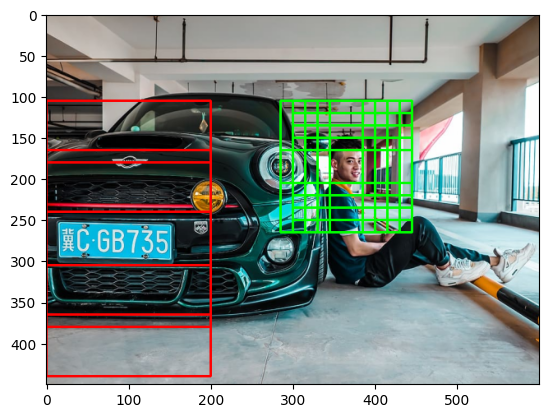

In [ ]:
print("[INFO] showing results for bbx")
clone = orig.copy()

for (box, prob) in f_bbx:
  (startX, startY, endX, endY) = box
  cv2.rectangle(clone, (startX, startY), (endX, endY),(0, 255, 0), 2)

for (box, prob) in p_bbx:
  (startX, startY, endX, endY) = box
  cv2.rectangle(clone, (startX, startY), (endX, endY),(0, 0, 255), 2)


plt.imshow(cv2.cvtColor(clone, cv2.COLOR_BGR2RGB))
plt.show()


[[330 150 430 250]
 [  0 165 200 365]]


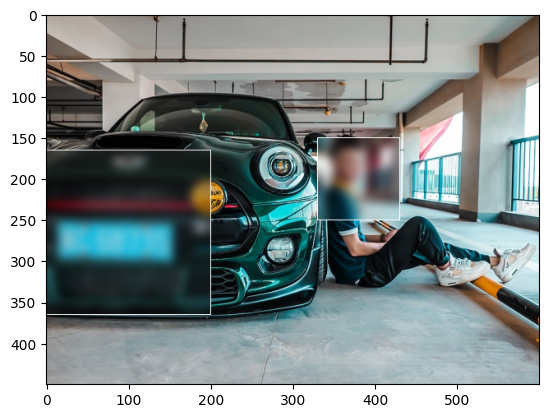

In [ ]:

f_boxes = np.array([p[0] for p in f_bbx])
f_proba = np.array([p[1].to('cpu') for p in f_bbx])

p_boxes = np.array([p[0] for p in p_bbx])
p_proba = np.array([p[1].to('cpu') for p in p_bbx])

boxes = non_max_suppression(f_boxes, f_proba, overlapThresh=0.3)
boxes = np.concatenate( (boxes ,non_max_suppression(p_boxes, p_proba, overlapThresh=0.3)) ,axis = 0 )

print(boxes)

clone = orig.copy()

for (startX, startY, endX, endY) in boxes:
    roi = clone[startY:endY,startX:endX]
    blurred_roi = cv2.GaussianBlur(roi, (35,35), 0)
    clone[startY:endY,startX:endX] = blurred_roi
    cv2.rectangle(clone, (startX, startY), (endX, endY),(255, 255, 255), 1)

plt.imshow(cv2.cvtColor(clone, cv2.COLOR_BGR2RGB))
plt.show()